<div style="max-width: 50%; margin-left: 0; text-align: left;">
Hierbeneden wordt de hoek van staaf 1 gekozen zodat het hefmechanisme zo hoog mogelijk kan opklappen zonder over het dode punt te gaan. Die optimale hoek bedraagt ongeveer 65°, zoals kan gezien worden op de grafiek.
</div>

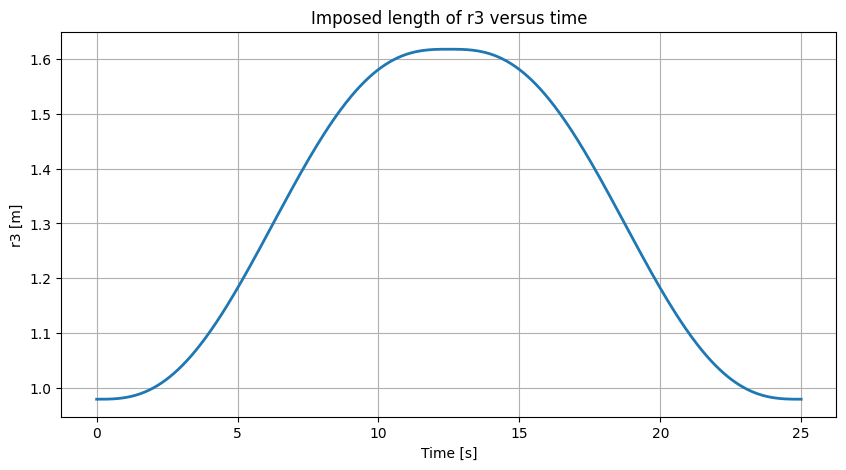

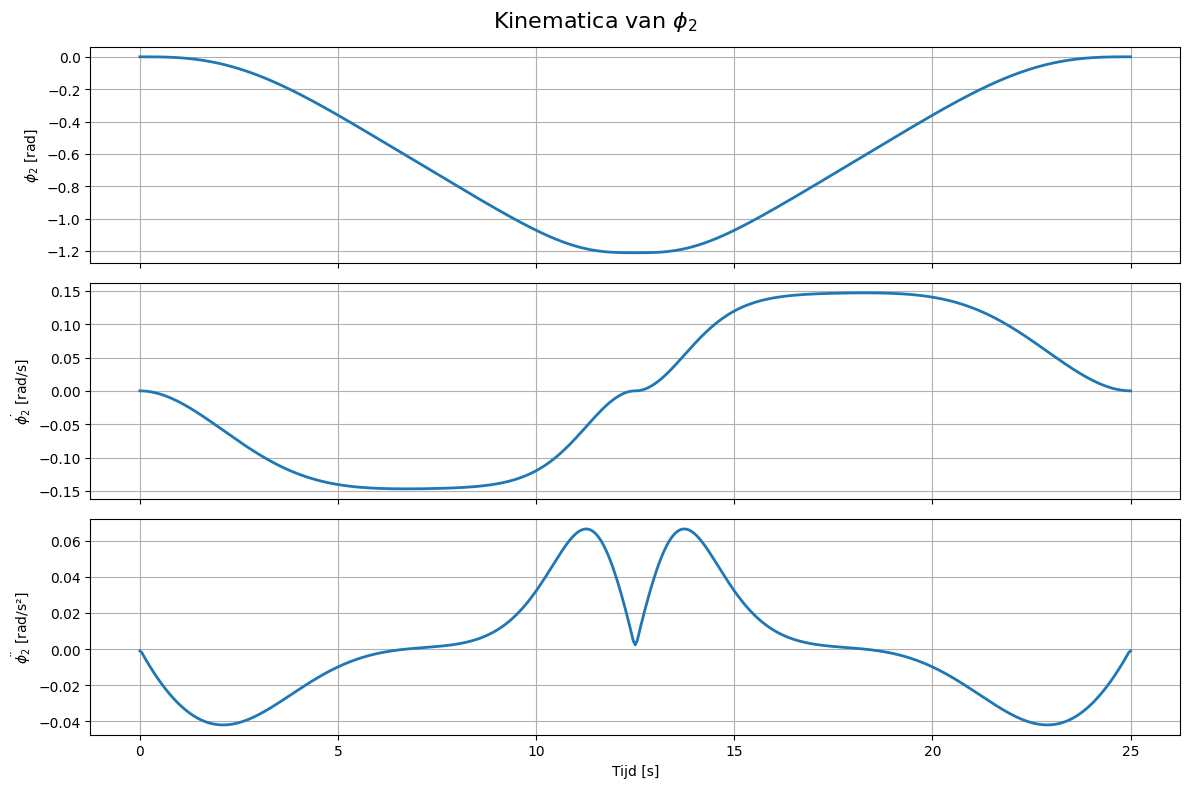

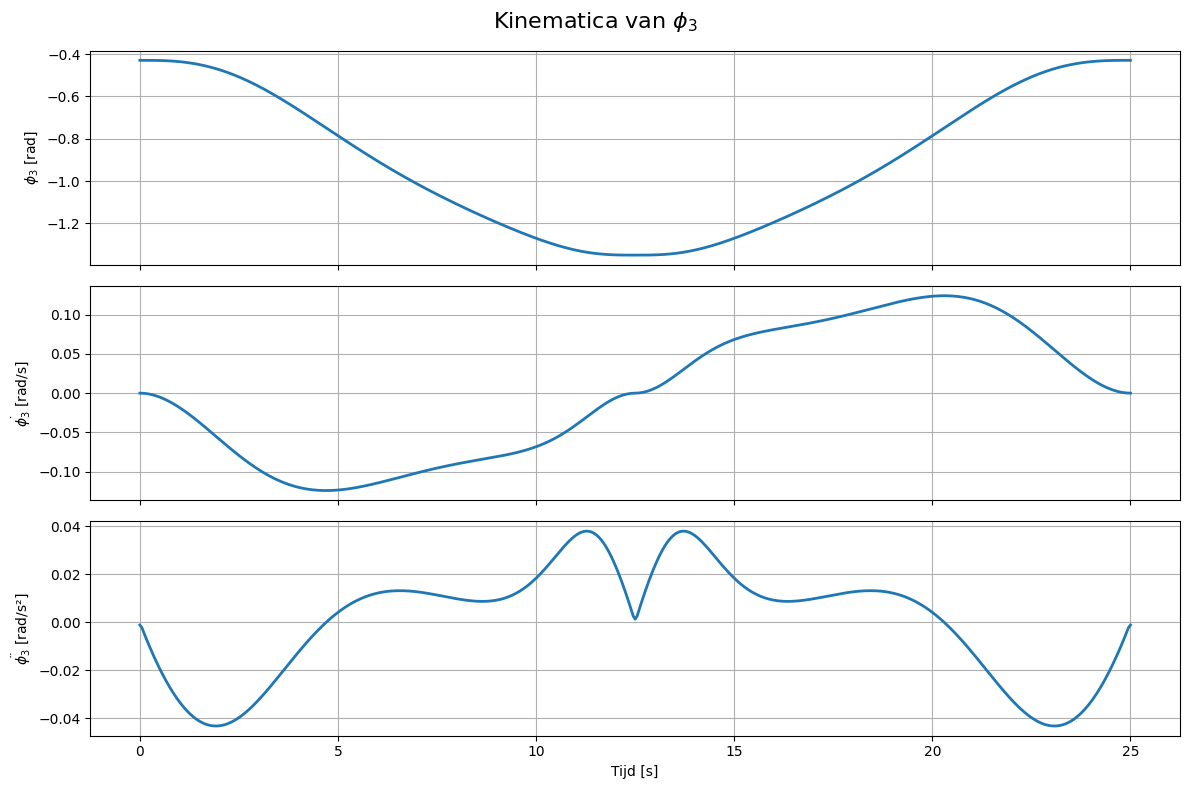

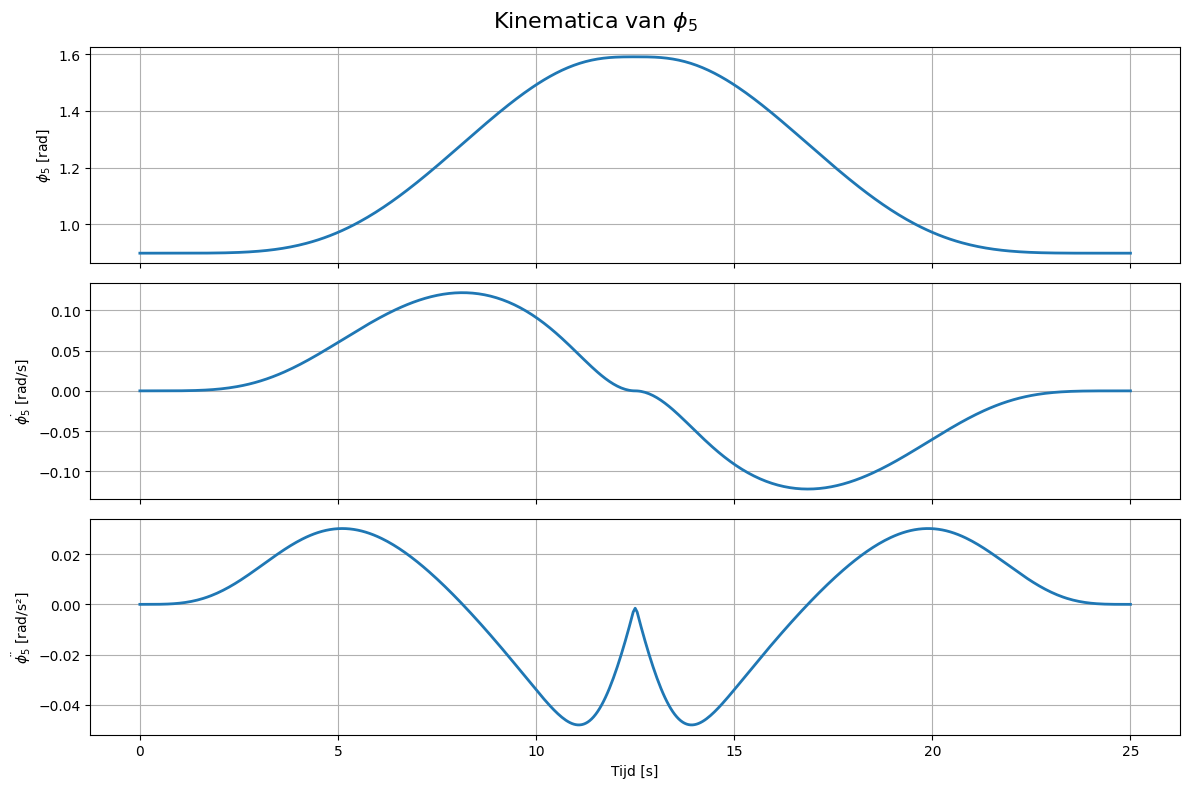

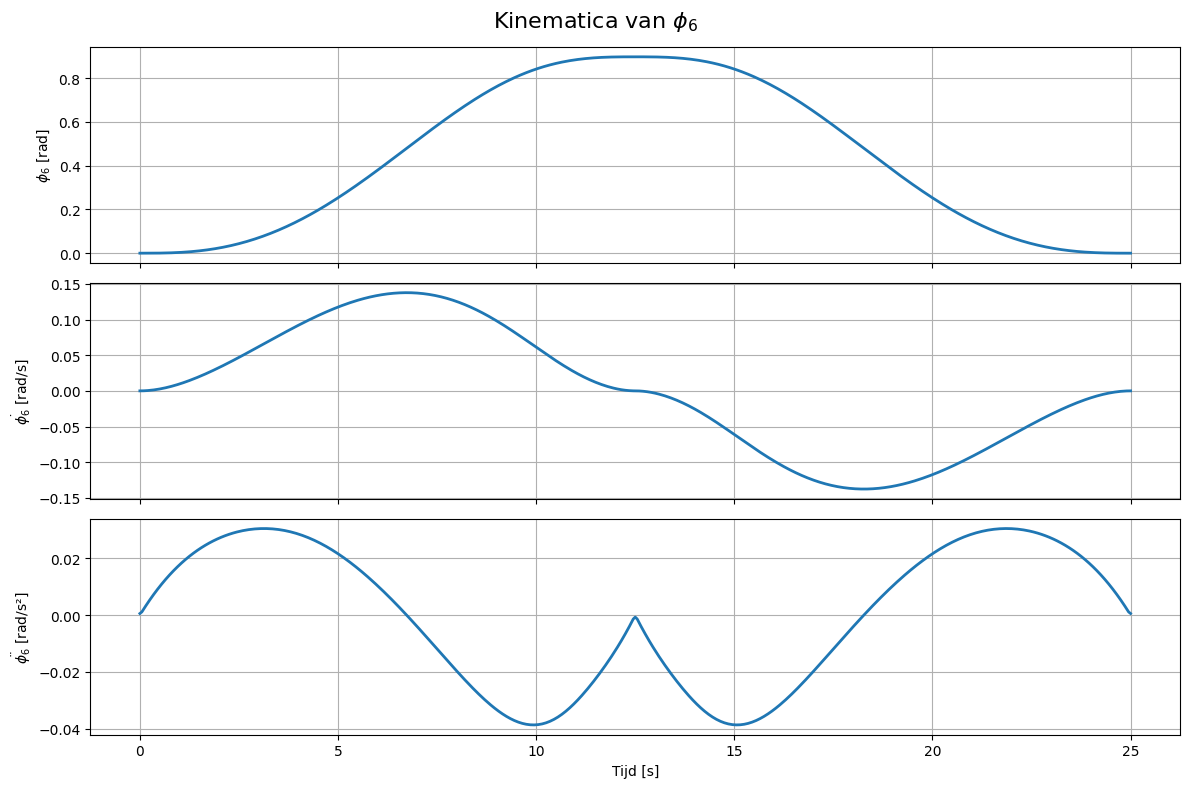

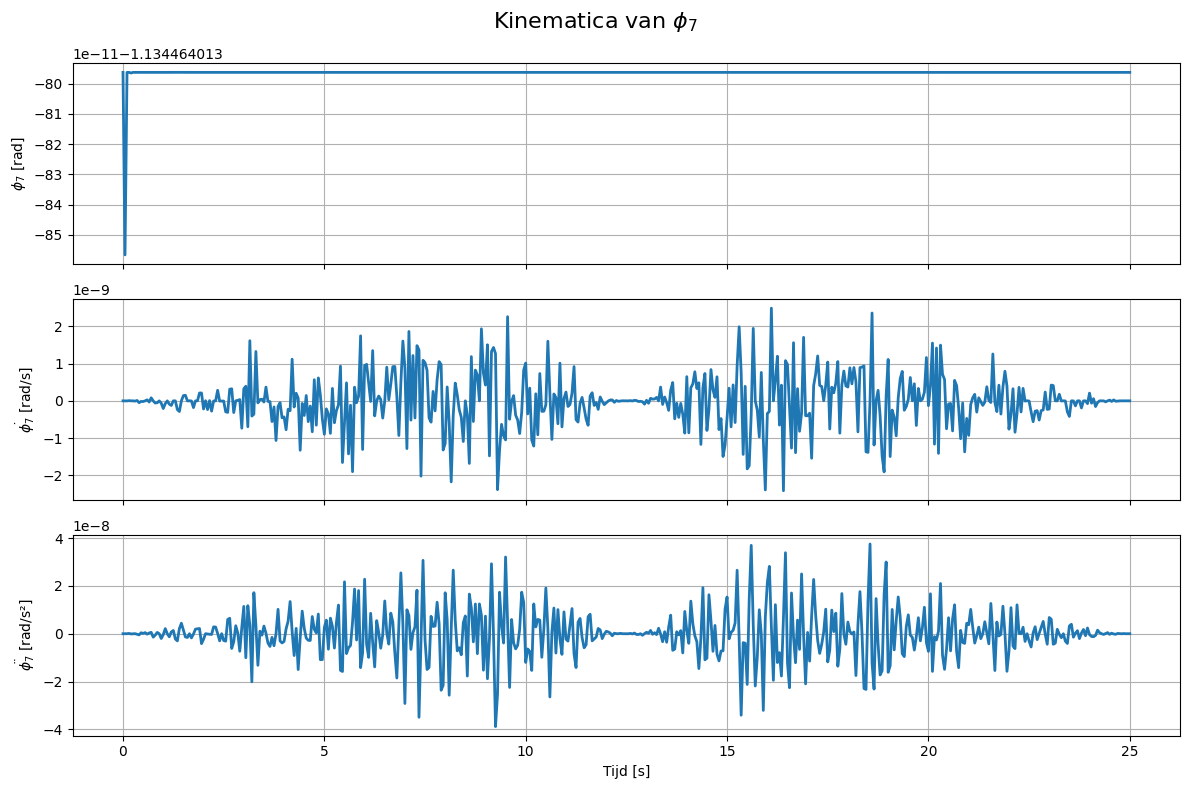

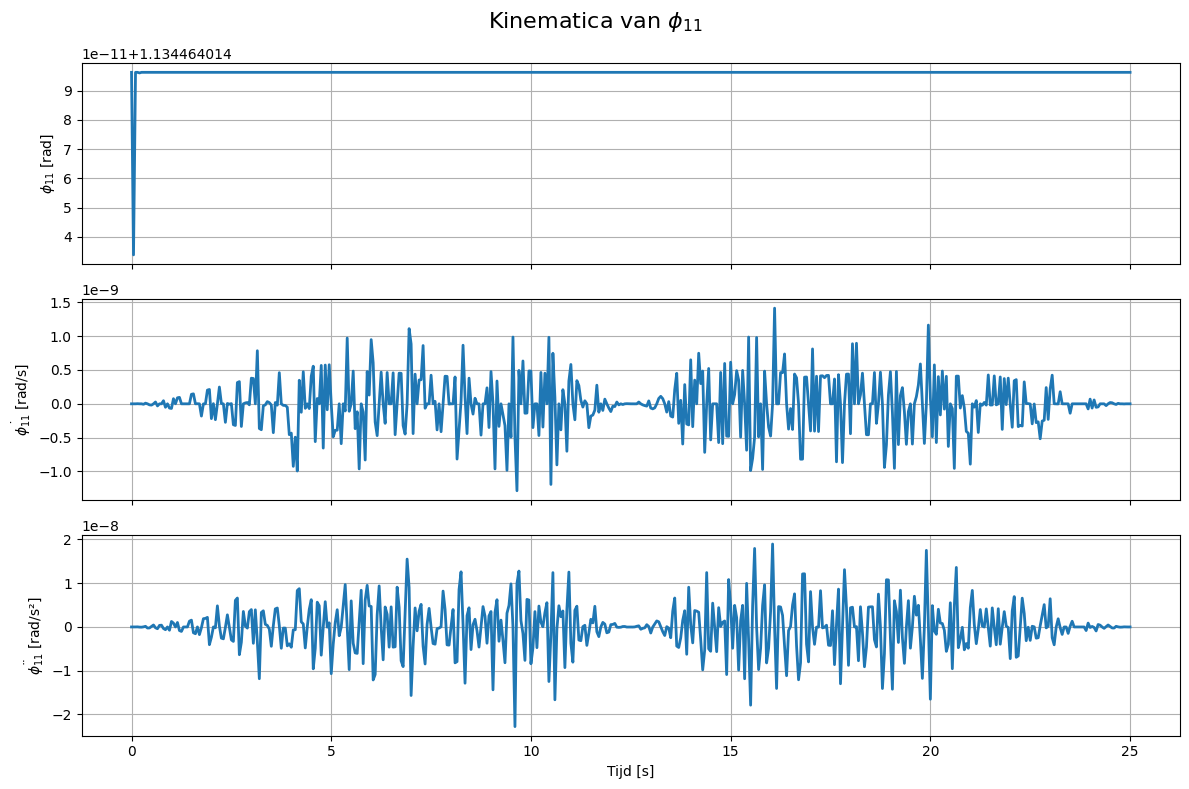

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display
# ==========================================================
# PARAMETERS PARAMETRIQUES
# ==========================================================

deg45 = np.deg2rad(65)

# Longueur principale modifiable
r2 = 1.00       # change uniquement celle-ci
r1 = 0.3

# Dépendances principales
r4r = r2
r6l = r1

r11 = r1
r7  = r11

# ==========================================================
# r4 dépend de r2 via r6l et r4r
# ==========================================================

den = np.sin(2*deg45) - 4*np.cos(deg45) + 4
num = np.sin(2*deg45) + 4*np.cos(deg45) - 2*np.cos(2*deg45) - 2

r4l = r6l * num / den
r4  = r4r + r4l

# ==========================================================
# r8 et r6 dépendent de r2
# ==========================================================

r8  = r2 + 2*r11*np.cos(deg45)
r6r = r8 - r6l
r6  = r6l + r6r

# ==========================================================
# r9 dépend de r11/r7
# ==========================================================

r9r = 1.5 * r11
r9l = r7
r9  = r9r + r9l

phi9_offset = -2 * deg45

# ==========================================================
# r5 et r3_init
# ==========================================================

h_EF = (r9r - r11/2) * np.sin(deg45)

r5 = np.sqrt(
    (r4 - r6r)**2
    + h_EF**2
)

# ==========================================================
# FIXED POINTS
# ==========================================================

A = np.array([0.0, 0.0])
C = A + r1*np.array([np.cos(deg45), np.sin(deg45)])
B = (A + C) / 2

# ==========================================================
# INITIAL ANGLES
# ==========================================================

phi2_init  = 0.0
phi4_init  = 0.0
phi6_init  = 0.0
phi8_init  = 0.0

phi7_init  = -deg45
phi11_init = deg45

phi5_init = np.arctan2(
    h_EF,
    r4 - r6r
)

r3_init = np.sqrt(
    (r6r - r11/2*np.cos(deg45))**2
    + (1.5*r11*np.sin(deg45))**2
)

phi3_init = -np.arctan2(
    1.5*r11*np.sin(deg45),
    r6r - r11/2*np.cos(deg45)
)
# ==========================================================
# TIME
# ==========================================================

t_begin = 0.0
t_end   = 25.0
Ts      = 0.05

t = np.arange(t_begin, t_end + Ts, Ts)
N = len(t)

# ==========================================================
# IMPOSED r3 MOTION
# ==========================================================

r3_max = np.sqrt((r5 + r4 - r1/2*np.cos(2*deg45))**2 + (r1/2*np.sin(2*deg45))**2)
dx = r3_max - r3_init
T = t_end - t_begin

def quintic_out_and_back(t, x0, dx, T):
    x = np.zeros_like(t, dtype=float)
    v = np.zeros_like(t, dtype=float)
    a = np.zeros_like(t, dtype=float)

    mask1 = (t >= 0) & (t <= T)
    tau1 = t[mask1] / T

    s1  = 10*tau1**3 - 15*tau1**4 + 6*tau1**5
    ds1 = 30*tau1**2 - 60*tau1**3 + 30*tau1**4
    dds1 = 60*tau1 - 180*tau1**2 + 120*tau1**3

    x[mask1] = x0 + dx*s1
    v[mask1] = dx/T * ds1
    a[mask1] = dx/T**2 * dds1

    mask2 = (t > T) & (t <= 2*T)
    tau2 = (t[mask2] - T) / T

    s2  = 10*tau2**3 - 15*tau2**4 + 6*tau2**5
    ds2 = 30*tau2**2 - 60*tau2**3 + 30*tau2**4
    dds2 = 60*tau2 - 180*tau2**2 + 120*tau2**3

    x[mask2] = x0 + dx*(1 - s2)
    v[mask2] = -dx/T * ds2
    a[mask2] = -dx/T**2 * dds2

    x[t < 0] = x0
    x[t > 2*T] = x0

    return x, v, a


r3, dr3, ddr3 = quintic_out_and_back(t, r3_init, dx, T/2)

# ==========================================================
# PLOT r3(t)
# ==========================================================

plt.figure(figsize=(10, 5))
plt.plot(t, r3, linewidth=2)
plt.xlabel("Time [s]")
plt.ylabel("r3 [m]")
plt.title("Imposed length of r3 versus time")
plt.grid(True)
plt.show()

# ==========================================================
# HELPERS
# ==========================================================

def unit(phi):
    return np.array([np.cos(phi), np.sin(phi)])

# ==========================================================
# SYSTEM
#
# Unknowns:
# phi2, phi3, phi4, phi5, phi6, phi7, phi8, phi11
#
# phi9 is not constant:
# phi9 = phi11 + phi9_offset
# ==========================================================

def system_equations(x, r3_k):

    phi2, phi3, phi4, phi5, phi6, phi7, phi8, phi11 = x

    phi9 = phi11 + phi9_offset

    # r4 : E/D -> C
    D = C - r4r * unit(phi4)
    E = C - r4  * unit(phi4)

    # r3 : F -> B
    F = B - r3_k * unit(phi3)

    # r11 : K -> D
    K = D - r11 * unit(phi11)
    M11 = D - (r11/2) * unit(phi11)

    # r9 : I/J -> M11
    J = M11 - r9r * unit(phi9)
    I = M11 - r9  * unit(phi9)

    # r6 : J -> F -> G
    G = J + (r6l + r6r) * unit(phi6)

    # r7 : H -> G
    H = G - r7 * unit(phi7)

    # Closures
    eq_EF = F - (E + r5 * unit(phi5))
    eq_KA = A - (K + r2 * unit(phi2))
    eq_JF = F - (J + r6l * unit(phi6))
    eq_HI = I - (H - r8 * unit(phi8))

    return np.concatenate([eq_EF, eq_KA, eq_JF, eq_HI])

# ==========================================================
# SOLVE POSITIONS
# ==========================================================

phi2  = np.zeros(N)
phi3  = np.zeros(N)
phi4  = np.zeros(N)
phi5  = np.zeros(N)
phi6  = np.zeros(N)
phi7  = np.zeros(N)
phi8  = np.zeros(N)
phi11 = np.zeros(N)

x_guess = np.array([
    phi2_init,
    phi3_init,
    phi4_init,
    phi5_init,
    phi6_init,
    phi7_init,
    phi8_init,
    phi11_init
])

for k in range(N):

    sol, info, ier, msg = fsolve(
        lambda x: system_equations(x, r3[k]),
        x_guess,
        full_output=True,
        maxfev=3000
    )

    residual = np.linalg.norm(system_equations(sol, r3[k]))

    if ier != 1 and residual > 1e-6:
        print(f"Attention convergence frame {k}")
        print(msg)
        print("residual =", residual)

    phi2[k], phi3[k], phi4[k], phi5[k], phi6[k], phi7[k], phi8[k], phi11[k] = sol

    x_guess = sol.copy()

# ==========================================================
# HOEKSNELHEDEN EN HOEKVERSNELLINGEN
# via afgeleide sluitingsvergelijkingen
# ==========================================================

def numerical_jacobian_q(func, q, r3_k, eps=1e-7):
    n = len(q)
    F0 = func(q, r3_k)
    J = np.zeros((len(F0), n))

    for i in range(n):
        q_eps = q.copy()
        q_eps[i] += eps
        F_eps = func(q_eps, r3_k)
        J[:, i] = (F_eps - F0) / eps

    return J


def numerical_jacobian_r3(func, q, r3_k, eps=1e-7):
    F0 = func(q, r3_k)
    F_eps = func(q, r3_k + eps)
    return (F_eps - F0) / eps


# matrix met alle hoeken
Q = np.column_stack([
    phi2,
    phi3,
    phi4,
    phi5,
    phi6,
    phi7,
    phi8,
    phi11
])

# arrays voor snelheden
dphi2  = np.zeros(N)
dphi3  = np.zeros(N)
dphi4  = np.zeros(N)
dphi5  = np.zeros(N)
dphi6  = np.zeros(N)
dphi7  = np.zeros(N)
dphi8  = np.zeros(N)
dphi11 = np.zeros(N)

# arrays voor versnellingen
ddphi2  = np.zeros(N)
ddphi3  = np.zeros(N)
ddphi4  = np.zeros(N)
ddphi5  = np.zeros(N)
ddphi6  = np.zeros(N)
ddphi7  = np.zeros(N)
ddphi8  = np.zeros(N)
ddphi11 = np.zeros(N)

# opslag van J en rechterlid b
J_list = np.zeros((N, 8, 8))
b_list = np.zeros((N, 8))

dQ = np.zeros((N, 8))
ddQ = np.zeros((N, 8))

# ==========================================================
# SNELHEDEN
#
# F(q, r3) = 0
# dF/dq * qdot + dF/dr3 * r3dot = 0
#
# J * qdot = -Fr * dr3
# ==========================================================

for k in range(N):

    q_k = Q[k, :]

    J = numerical_jacobian_q(system_equations, q_k, r3[k])
    Fr = numerical_jacobian_r3(system_equations, q_k, r3[k])

    b = -Fr * dr3[k]

    qdot = np.linalg.solve(J, b)

    J_list[k, :, :] = J
    b_list[k, :] = b
    dQ[k, :] = qdot

# ==========================================================
# VERSNELLINGEN
#
# J*qdot = b
# d/dt(J*qdot) = d/dt(b)
# J*qddot + Jdot*qdot = bdot
#
# J*qddot = bdot - Jdot*qdot
# ==========================================================

Jdot_list = np.gradient(J_list, Ts, axis=0)
bdot_list = np.gradient(b_list, Ts, axis=0)

for k in range(N):

    J = J_list[k, :, :]
    Jdot = Jdot_list[k, :, :]
    bdot = bdot_list[k, :]

    qdot = dQ[k, :]

    rhs_a = bdot - Jdot @ qdot

    qddot = np.linalg.solve(J, rhs_a)

    ddQ[k, :] = qddot

# uitschrijven naar aparte variabelen
dphi2  = dQ[:, 0]
dphi3  = dQ[:, 1]
dphi4  = dQ[:, 2]
dphi5  = dQ[:, 3]
dphi6  = dQ[:, 4]
dphi7  = dQ[:, 5]
dphi8  = dQ[:, 6]
dphi11 = dQ[:, 7]

ddphi2  = ddQ[:, 0]
ddphi3  = ddQ[:, 1]
ddphi4  = ddQ[:, 2]
ddphi5  = ddQ[:, 3]
ddphi6  = ddQ[:, 4]
ddphi7  = ddQ[:, 5]
ddphi8  = ddQ[:, 6]
ddphi11 = ddQ[:, 7]

# ==========================================================
# MECHANISM POINTS
# ==========================================================

def mechanism_points(k):

    phi9 = phi11[k] + phi9_offset

    D = C - r4r * unit(phi4[k])
    E = C - r4  * unit(phi4[k])

    F = B - r3[k] * unit(phi3[k])

    K = D - r11 * unit(phi11[k])
    M11 = D - (r11/2) * unit(phi11[k])

    J = M11 - r9r * unit(phi9)
    I = M11 - r9  * unit(phi9)

    G = J + (r6l + r6r) * unit(phi6[k])
    H = G - r7 * unit(phi7[k])

    return A, B, C, D, E, F, G, H, I, J, K, M11

# ==========================================================
# ANIMATION
# ==========================================================

plt.ioff()

fig, ax = plt.subplots(figsize=(9, 7))

index_vec = np.arange(0, N, 5, dtype=int)

x_left   = -2
x_right  =  1
y_bottom = -0.1
y_top    =  2.4

def update(frame_idx):

    k = index_vec[frame_idx]

    ax.clear()
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlim(x_left, x_right)
    ax.set_ylim(y_bottom, y_top)
    ax.grid(True)

    ax.set_xlabel("[m]")
    ax.set_ylabel("[m]")
    ax.set_title(f"Positions - frame {k} - t = {t[k]:.2f} s")

    A_, B_, C_, D, E, F, G, H, I, J, K, M11 = mechanism_points(k)

    ax.plot([A_[0], B_[0], C_[0]],
            [A_[1], B_[1], C_[1]],
            "-o", linewidth=3, label="r1")

    ax.plot([B_[0], F[0]],
            [B_[1], F[1]],
            "-o", linewidth=2, label="r3")

    ax.plot([C_[0], D[0], E[0]],
            [C_[1], D[1], E[1]],
            "-o", linewidth=2, label="r4l + r4r")

    ax.plot([E[0], F[0]],
            [E[1], F[1]],
            "-o", linewidth=2, label="r5")

    ax.plot([K[0], A_[0]],
            [K[1], A_[1]],
            "-o", linewidth=2, label="r2")

    ax.plot([K[0], M11[0], D[0]],
            [K[1], M11[1], D[1]],
            "-o", linewidth=2, label="r11")

    ax.plot([M11[0], J[0], I[0]],
            [M11[1], J[1], I[1]],
            "-o", linewidth=2, label="r9l + r9r")

    ax.plot([J[0], F[0], G[0]],
            [J[1], F[1], G[1]],
            "-o", linewidth=2, label="r6")

    # r7 : H -> G
    ax.plot(
        [H[0], G[0]],
        [H[1], G[1]],
        "-o",
        linewidth=2,
        label="r7"
    )

    # r8 : I -> H
    ax.plot(
        [I[0], H[0]],
        [I[1], H[1]],
        "-o",
        linewidth=2,
        label="r8"
    )

    points = {
        "A": A_,
        "B": B_,
        "C": C_,
        "D": D,
        "E": E,
        "F": F,
        "G": G,
        "H": H,
        "I": I,
        "J": J,
        "K": K
    }

    for name, point in points.items():
        ax.text(point[0] + 0.02, point[1] + 0.02, name, fontsize=10)

    ax.legend(loc="upper right", fontsize=8)

    return []

ani = FuncAnimation(
    fig,
    update,
    frames=len(index_vec),
    interval=50,
    blit=False
)

plt.close(fig)

display(HTML(ani.to_jshtml()))

# ==========================================================
# PLOTS KINEMATICA
# ==========================================================

def plot_kinematics(t, phi, dphi, ddphi, name):
    fig, axs = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

    axs[0].plot(t, phi, linewidth=2)
    axs[0].set_ylabel(fr'${name}$ [rad]')
    axs[0].grid(True)

    axs[1].plot(t, dphi, linewidth=2)
    axs[1].set_ylabel(fr'$\dot{{{name}}}$ [rad/s]')
    axs[1].grid(True)

    axs[2].plot(t, ddphi, linewidth=2)
    axs[2].set_ylabel(fr'$\ddot{{{name}}}$ [rad/s²]')
    axs[2].set_xlabel('Tijd [s]')
    axs[2].grid(True)

    fig.suptitle(fr'Kinematica van ${name}$', fontsize=16)
    plt.tight_layout()
    plt.show()

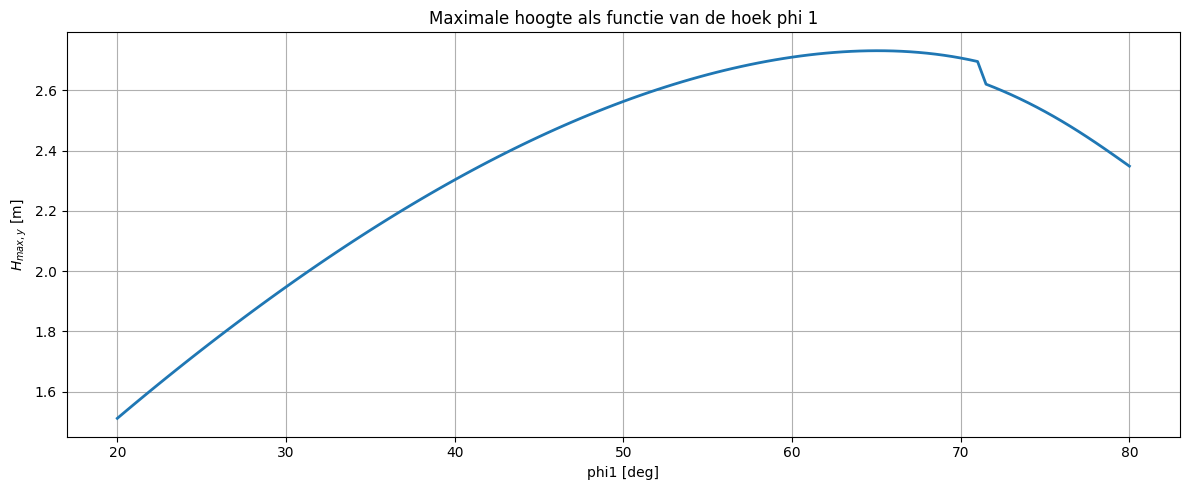

In [2]:
# ==========================================================
# Hmax EN FONCTION DE deg45
# de 20° à 80°
# ==========================================================

deg_vec = np.deg2rad(np.linspace(20, 80, 121))
deg_plot = np.rad2deg(deg_vec)

Hmax_vec = np.zeros_like(deg_vec)

# sauvegarde de la valeur initiale globale si besoin
r2_base = r2

for i, deg45_i in enumerate(deg_vec):

    # ------------------------------------------------------
    # Recalcul géométrie pour chaque angle
    # ------------------------------------------------------

    r2 = r2_base

    ratio_r1  = 0.30
    ratio_r4r = 1.00
    ratio_r6l = 0.30

    r1  = ratio_r1  * r2
    r4r = ratio_r4r * r2
    r6l = ratio_r6l * r2

    r11 = r1
    r7  = r11

    den = np.sin(2*deg45_i) - 4*np.cos(deg45_i) + 4
    num = np.sin(2*deg45_i) + 4*np.cos(deg45_i) - 2*np.cos(2*deg45_i) - 2

    r4l = r6l * num / den
    r4  = r4r + r4l

    r8  = r2 + 2*r11*np.cos(deg45_i)
    r6r = r8 - r6l
    r6  = r6l + r6r

    r9r = 1.5 * r11
    r9l = r7
    r9  = r9r + r9l

    phi9_offset_i = -2 * deg45_i

    h_EF = (r9r - r11/2) * np.sin(deg45_i)

    r5 = np.sqrt(
        (r4 - r6r)**2
        + h_EF**2
    )

    A_i = np.array([0.0, 0.0])
    C_i = A_i + r1*np.array([np.cos(deg45_i), np.sin(deg45_i)])
    B_i = (A_i + C_i) / 2

    phi2_init_i  = 0.0
    phi4_init_i  = 0.0
    phi6_init_i  = 0.0
    phi8_init_i  = 0.0
    phi7_init_i  = -deg45_i
    phi11_init_i = deg45_i

    phi5_init_i = np.arctan2(
        h_EF,
        r4 - r6r
    )

    r3_init_i = np.sqrt(
        (r6r - r11/2*np.cos(deg45_i))**2
        + (1.5*r11*np.sin(deg45_i))**2
    )

    phi3_init_i = -np.arctan2(
        1.5*r11*np.sin(deg45_i),
        r6r - r11/2*np.cos(deg45_i)
    )

    # ------------------------------------------------------
    # r3_max : limite quand r5 est parallèle à r4
    # ------------------------------------------------------

    r3_max = np.sqrt((r5 + r4 - r1/2*np.cos(2*deg45))**2 + (r1/2*np.sin(2*deg45))**2)

    # ------------------------------------------------------
    # Fonctions locales
    # ------------------------------------------------------

    def unit_i(phi):
        return np.array([np.cos(phi), np.sin(phi)])

    def system_equations_i(x, r3_k):

        phi2_i, phi3_i, phi4_i, phi5_i, phi6_i, phi7_i, phi8_i, phi11_i = x

        phi9_i = phi11_i + phi9_offset_i

        D_i = C_i - r4r * unit_i(phi4_i)
        E_i = C_i - r4  * unit_i(phi4_i)

        F_i = B_i - r3_k * unit_i(phi3_i)

        K_i = D_i - r11 * unit_i(phi11_i)
        M11_i = D_i - (r11/2) * unit_i(phi11_i)

        J_i = M11_i - r9r * unit_i(phi9_i)
        I_i = M11_i - r9  * unit_i(phi9_i)

        G_i = J_i + r6 * unit_i(phi6_i)
        H_i = G_i - r7 * unit_i(phi7_i)

        eq_EF = F_i - (E_i + r5 * unit_i(phi5_i))
        eq_KA = A_i - (K_i + r2 * unit_i(phi2_i))
        eq_JF = F_i - (J_i + r6l * unit_i(phi6_i))
        eq_HI = I_i - (H_i - r8 * unit_i(phi8_i))

        return np.concatenate([eq_EF, eq_KA, eq_JF, eq_HI])

    def H_y_from_solution(q, r3_k):

        phi2_i, phi3_i, phi4_i, phi5_i, phi6_i, phi7_i, phi8_i, phi11_i = q

        phi9_i = phi11_i + phi9_offset_i

        D_i = C_i - r4r * unit_i(phi4_i)
        M11_i = D_i - (r11/2) * unit_i(phi11_i)

        J_i = M11_i - r9r * unit_i(phi9_i)

        G_i = J_i + r6 * unit_i(phi6_i)
        H_i = G_i - r7 * unit_i(phi7_i)

        return H_i[1]

    # ------------------------------------------------------
    # H max directement pour r3 = r3_max_i
    # ------------------------------------------------------

    r3_max_i = np.sqrt(
        (r5 + r4 - r1/2*np.cos(2*deg45_i))**2
        + (r1/2*np.sin(2*deg45_i))**2
    )

    q_guess = np.array([
        phi2_init_i,
        phi3_init_i,
        phi4_init_i,
        phi5_init_i,
        phi6_init_i,
        phi7_init_i,
        phi8_init_i,
        phi11_init_i
    ])

    sol, info, ier, msg = fsolve(
        lambda q: system_equations_i(q, r3_max_i),
        q_guess,
        full_output=True,
        maxfev=3000
    )

    residual = np.linalg.norm(system_equations_i(sol, r3_max_i))

    if ier == 1 or residual < 1e-6:
        Hmax_vec[i] = H_y_from_solution(sol, r3_max_i)
    else:
        Hmax_vec[i] = np.nan
        print(f"Pas de convergence pour deg = {np.rad2deg(deg45_i):.1f}°, residual = {residual}")


# ==========================================================
# PLOT Hmax(deg45)
# ==========================================================

plt.figure(figsize=(12,5))

plt.plot(deg_plot, Hmax_vec, linewidth=2)

plt.xlabel("phi1 [deg]")
plt.ylabel(r"$H_{max,y}$ [m]")

plt.title(r"Maximale hoogte als functie van de hoek phi 1")

plt.grid(True)
plt.tight_layout()

plt.show()